MONTE CARLO SIMULATION
Total Points       : 10000
Points Inside      : 7877
Points Outside     : 2123
Estimated Pi Value : 3.150800
Actual Pi Value    : 3.141593
Absolute Error     : 0.009207

Summary Table
           Metric         Value
0    Total Points  10000.000000
1   Inside Circle   7877.000000
2  Outside Circle   2123.000000
3    Estimated Pi      3.150800
4       Actual Pi      3.141593
5  Absolute Error      0.009207


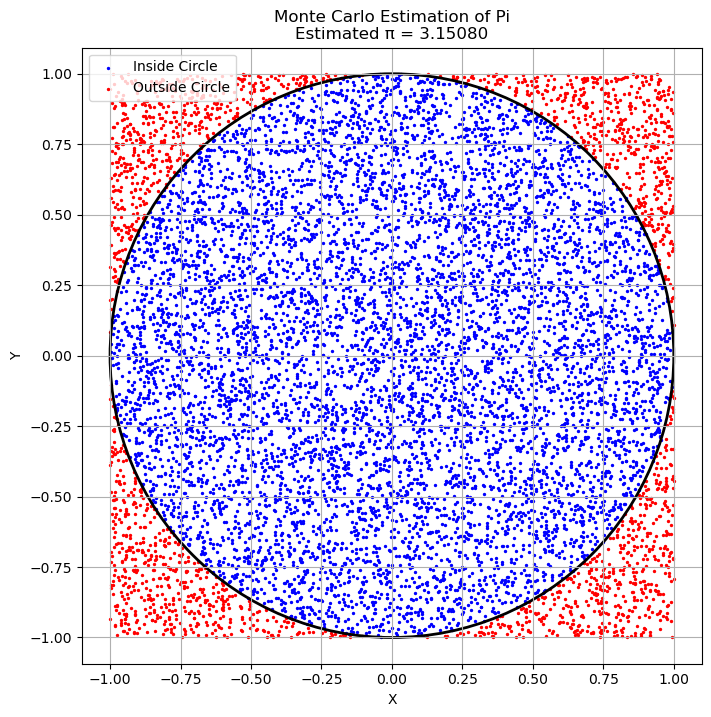

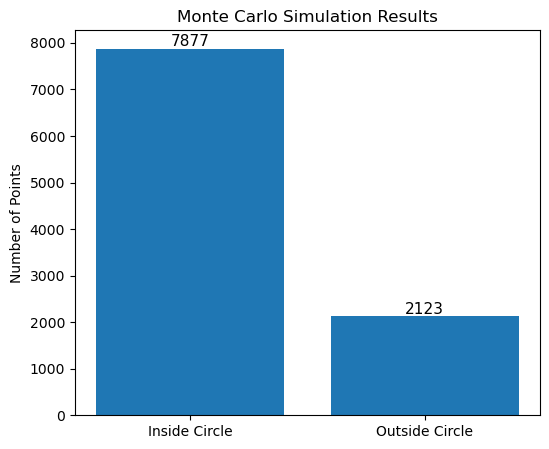

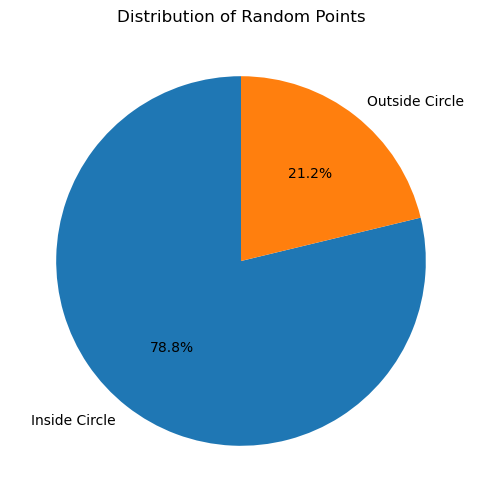

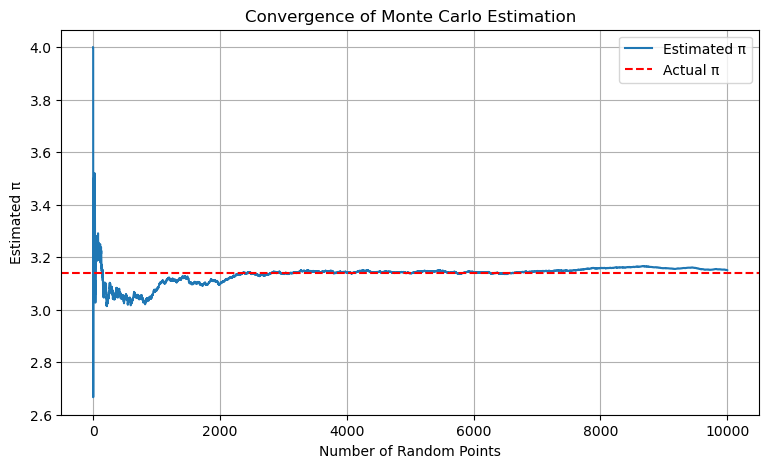

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Number of random points
num_points = 10000

# Generate random points
x = np.random.uniform(-1, 1, num_points)
y = np.random.uniform(-1, 1, num_points)

# Check if points are inside the circle
inside = (x**2 + y**2) <= 1

inside_count = np.sum(inside)
outside_count = num_points - inside_count

# Estimate Pi
estimated_pi = 4 * inside_count / num_points

print("=" * 50)
print("MONTE CARLO SIMULATION")
print("=" * 50)
print(f"Total Points       : {num_points}")
print(f"Points Inside      : {inside_count}")
print(f"Points Outside     : {outside_count}")
print(f"Estimated Pi Value : {estimated_pi:.6f}")
print(f"Actual Pi Value    : {np.pi:.6f}")
print(f"Absolute Error     : {abs(np.pi-estimated_pi):.6f}")

# Summary Table
summary = pd.DataFrame({
    "Metric":[
        "Total Points",
        "Inside Circle",
        "Outside Circle",
        "Estimated Pi",
        "Actual Pi",
        "Absolute Error"
    ],
    "Value":[
        num_points,
        inside_count,
        outside_count,
        round(estimated_pi,6),
        round(np.pi,6),
        round(abs(np.pi-estimated_pi),6)
    ]
})

print("\nSummary Table")
print(summary)

# Visualization
plt.figure(figsize=(8,8))

plt.scatter(x[inside], y[inside],
            color='blue',
            s=2,
            label='Inside Circle')

plt.scatter(x[~inside], y[~inside],
            color='red',
            s=2,
            label='Outside Circle')

circle = plt.Circle((0,0),1,color='black',fill=False,linewidth=2)
plt.gca().add_artist(circle)

plt.title(f"Monte Carlo Estimation of Pi\nEstimated π = {estimated_pi:.5f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(6,5))

categories = ['Inside Circle', 'Outside Circle']
values = [inside_count, outside_count]

plt.bar(categories, values)

plt.title("Monte Carlo Simulation Results")
plt.ylabel("Number of Points")

for i, v in enumerate(values):
    plt.text(i, v+50, str(v), ha='center', fontsize=11)

plt.show()

plt.figure(figsize=(6,6))

labels = ['Inside Circle', 'Outside Circle']
sizes = [inside_count, outside_count]

plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribution of Random Points")
plt.show()

pi_values = []
inside_running = 0

for i in range(num_points):
    if inside[i]:
        inside_running += 1
    pi_values.append(4 * inside_running / (i + 1))

plt.figure(figsize=(9,5))

plt.plot(pi_values, label="Estimated π")
plt.axhline(np.pi,
            color='red',
            linestyle='--',
            label='Actual π')

plt.xlabel("Number of Random Points")
plt.ylabel("Estimated π")
plt.title("Convergence of Monte Carlo Estimation")
plt.legend()
plt.grid(True)

plt.show()